In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('HousingData.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
print("Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.isnull().sum(axis=0)

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

<Axes: >

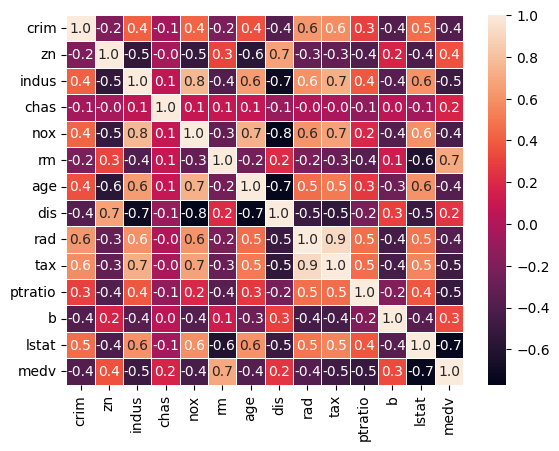

In [8]:
corr_mat = df.corr()
sns.heatmap(data=corr_mat, fmt=".1f", annot=True, linewidth='.5')

In [9]:
# cols = df.columns

# for col in cols:
#     sns.histplot(df[col], bins=30, kde=True)
#     plt.title(col)
#     plt.show()

In [10]:
X = df.drop(columns=['medv']).values
y = df['medv'].values

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [18]:
xmean = np.mean(X, axis=0) 
xstd = np.std(X, axis=0)

X_train = (X_train - xmean)/xstd
X_test = (X_test - xmean)/xstd

In [19]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    total_cost = 0

    for i in range(m):
        f_wb = np.dot(x[i], w) + b
        mse = (y[i] - f_wb)**2
        total_cost += mse
    
    final_cost = (1/(2*m)) * total_cost
    return final_cost

In [20]:
# computes gradient of cost function

# (daba(w, b)/daba(w)) = (1/m) * summation[xi*(f - yi)]
# (daba(w, b)/daba(b)) = (1/m) * summation[(f - yi)]
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    
    dc_dw = 0
    dc_db = 0

    for i in range(m):
        f = np.dot(x[i], w) + b

        dc_dw += x[i] * (f - y[i])
        dc_db += f - y[i]
    
    dc_dw = (1/m) * dc_dw
    dc_db = (1/m) * dc_db

    return dc_dw, dc_db


In [21]:
# w_new = w - (alpha)(daba(w, b)/daba(w))
# b_new = w - (alpha)(daba(w, b)/daba(b))

def gradiend_descent(x, y, alpha, iterations):
    w = np.zeros(x.shape[1])
    b = 0

    for i in range(iterations):
        dc_dw, dc_db = compute_gradient(x, y, w, b)

        w = w - alpha * dc_dw
        b = b - alpha *  dc_db

        print(f"Iteration {i}: Cost: {compute_cost(x, y, w, b)}")
    return w, b

In [22]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradiend_descent(X_train, y_train, learning_rate, iterations)

print(f"Final Weight: {final_w}")
print(f"Final bias: {final_b}")


Iteration 0: Cost: 295.3667157321316
Iteration 1: Cost: 287.83828233591225
Iteration 2: Cost: 280.65904685879883
Iteration 3: Cost: 273.7993266752447
Iteration 4: Cost: 267.2326817829895
Iteration 5: Cost: 260.93553901703115
Iteration 6: Cost: 254.88686033097045
Iteration 7: Cost: 249.06784996595286
Iteration 8: Cost: 243.46169593654702
Iteration 9: Cost: 238.0533418004197
Iteration 10: Cost: 232.82928515292195
Iteration 11: Cost: 227.77739970621514
Iteration 12: Cost: 222.8867781818478
Iteration 13: Cost: 218.14759357153096
Iteration 14: Cost: 213.55097660839763
Iteration 15: Cost: 209.08890754474166
Iteration 16: Cost: 204.75412055610173
Iteration 17: Cost: 200.54001928910395
Iteration 18: Cost: 196.4406022447835
Iteration 19: Cost: 192.45039684292624
Iteration 20: Cost: 188.56440114868485
Iteration 21: Cost: 184.7780323624953
Iteration 22: Cost: 181.08708127998725
Iteration 23: Cost: 177.48767202184223
Iteration 24: Cost: 173.9762264158266
Iteration 25: Cost: 170.54943248584325
Iter

In [23]:
y_pred = np.dot(X_test, final_w) + final_b

In [24]:
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_res = np.sum((y_test - y_pred)**2)

r2 = 1 - (ss_res/ss_total)

print("R2 Score (Manual Gradient Descent):", r2)

R2 Score (Manual Gradient Descent): 0.6687284639240151


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = lr.predict(X_test)

In [16]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

0.6687594935356321
